# Práctica 1 - Aprendizaje Automático

## Predicción de suscripción a depósito bancario

- Miembro 1: Jorge López ALonso + 100495876
- Miembro 2: Álvaro Carrasco Fuentes + 100495918
- Semilla usada: 13

En esta entrega hemos dejado cerrada la parte inicial:
- EDA simplificado y comprobaciones básicas de calidad de datos.
- Definición de estrategia de evaluación (outer holdout + inner CV).
- Primera comparación de modelos base (Dummy, KNN y árbol).

En las siguientes entregas añadiremos HPO, modelos avanzados, selección final y despliegue.

In [3]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

SEED = 13
MAIN_METRIC = make_scorer(f1_score, pos_label='yes')

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

In [4]:
df = pd.read_pickle('bank_13.pkl')
df_comp = pd.read_pickle('bank_competition_13.pkl')

target_col = 'deposit'
feature_cols = [c for c in df.columns if c != target_col]

summary = pd.DataFrame({
    'dtype': df[feature_cols].dtypes.astype(str),
    'n_unique': df[feature_cols].nunique(),
    'n_missing': df[feature_cols].isna().sum(),
    'missing_pct': (df[feature_cols].isna().mean() * 100).round(2),
})
summary['high_cardinality_gt10'] = summary['n_unique'] > 10
summary['is_constant'] = summary['n_unique'] <= 1
summary['looks_like_id'] = summary.index.str.lower().str.contains('id')

print('Train shape:', df.shape)
print('Competition shape:', df_comp.shape)
print('Problema: clasificación binaria')
display(summary.sort_values(['n_missing', 'n_unique'], ascending=[False, False]))

print('pdays == -1 (%):', round((df['pdays'] == -1).mean() * 100, 2))

Train shape: (11000, 17)
Competition shape: (162, 16)
Problema: clasificación binaria


,dtype,n_unique,n_missing,missing_pct,high_cardinality_gt10,is_constant,looks_like_id
marital,object,3,406,3.69,False,False,False
balance,int64,3783,0,0.00,True,False,False
duration,int64,1423,0,0.00,True,False,False
pdays,int64,472,0,0.00,True,False,False
age,int64,76,0,0.00,True,False,False
campaign,int64,36,0,0.00,True,False,False
previous,int64,34,0,0.00,True,False,False
day,int64,31,0,0.00,True,False,False
job,object,12,0,0.00,True,False,False
month,object,12,0,0.00,True,False,False


pdays == -1 (%): 74.57


In [5]:
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, stratify=y, random_state=SEED
)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def add_pdays_features(dataframe):
    data = dataframe.copy()
    data['pdays_no_prev_contact'] = (data['pdays'] == -1).astype(int)
    data['pdays'] = data['pdays'].replace(-1, np.nan)
    return data

def build_preprocessor(scaler_name='standard'):
    scaler_map = {'minmax': MinMaxScaler(), 'standard': StandardScaler(), 'robust': RobustScaler()}
    sample = add_pdays_features(X_train.head(5))
    num_cols = sample.select_dtypes(include=['number']).columns.tolist()
    cat_cols = [c for c in sample.columns if c not in num_cols]

    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', scaler_map[scaler_name])])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
    return ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

def build_pipeline(model, scaler_name='standard'):
    return Pipeline([
        ('pdays_fix', FunctionTransformer(add_pdays_features, validate=False)),
        ('prep', build_preprocessor(scaler_name=scaler_name)),
        ('model', model),
    ])

def evaluate_default(name, model, scaler_name='standard'):
    pipe = build_pipeline(model, scaler_name=scaler_name)
    start = time.perf_counter()
    cv = cross_validate(pipe, X_train, y_train, scoring=MAIN_METRIC, cv=inner_cv, n_jobs=-1)
    return {
        'model': name,
        'cv_f1_mean': float(np.mean(cv['test_score'])),
        'time_seconds': time.perf_counter() - start,
    }

,model,cv_f1_mean,time_seconds
0,Tree default,0.786112,0.146799
1,KNN default (standard),0.776231,1.933999
2,KNN default (standard),0.776231,0.143356
3,KNN default (robust),0.752552,0.197734
4,KNN default (minmax),0.693135,2.302818
5,Dummy (most_frequent),0.000000,2.679905


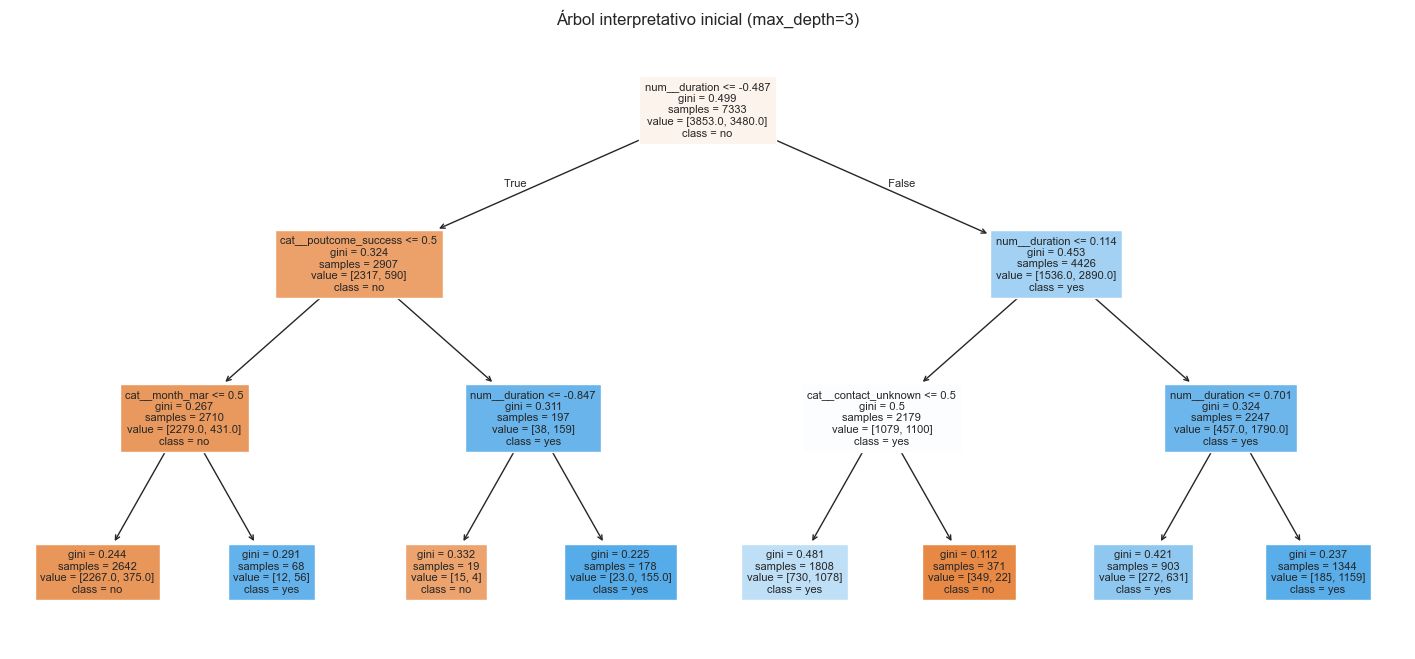

In [6]:
rows = []
rows.append(evaluate_default('Dummy (most_frequent)', DummyClassifier(strategy='most_frequent', random_state=SEED)))

for scaler in ['minmax', 'standard', 'robust']:
    rows.append(evaluate_default(f'KNN default ({scaler})', KNeighborsClassifier(), scaler_name=scaler))

best_scaler = max(rows[1:], key=lambda x: x['cv_f1_mean'])['model'].split('(')[-1].replace(')','')
rows.append(evaluate_default('Tree default', DecisionTreeClassifier(random_state=SEED), scaler_name='standard'))
rows.append(evaluate_default(f'KNN default ({best_scaler})', KNeighborsClassifier(), scaler_name=best_scaler))

results_defaults = pd.DataFrame(rows).sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
display(results_defaults)

interp_tree = build_pipeline(DecisionTreeClassifier(max_depth=3, random_state=SEED), scaler_name='standard')
interp_tree.fit(X_train, y_train)
tree_model = interp_tree.named_steps['model']
feature_names = interp_tree.named_steps['prep'].get_feature_names_out()

plt.figure(figsize=(18, 8))
plot_tree(tree_model, feature_names=feature_names, class_names=['no', 'yes'], filled=True, max_depth=3, fontsize=8)
plt.title('Árbol interpretativo inicial (max_depth=3)')
plt.show()

## Próximos pasos

1. Ajuste de hiperparámetros de KNN y árboles.
2. Comparativa de modelos lineales y SVM.
3. Selección final + evaluación en test + matriz de confusión.
4. Guardado de `modelo_final.joblib` y generación de `predicciones.csv`.
5. Completar app de Streamlit y comprobar dos ejemplos de predicción.